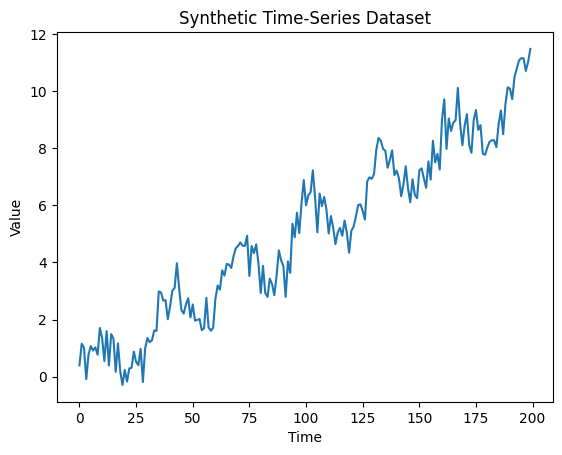

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

time=np.arange(0,200)

# (linear + sinusoidal)

value=0.05*time+np.sin(0.2*time)



noise=np.random.normal(0,0.5,len(time))

value=value+noise

data=pd.DataFrame({

'time':time,

'value':value

})


data.to_csv('dataset.csv',index=False)


plt.figure()

plt.plot(time,value)

plt.title('Synthetic Time-Series Dataset')

plt.xlabel('Time')

plt.ylabel('Value')

plt.show()

In [9]:
value

array([ 0.        ,  0.24866933,  0.48941834,  0.71464247,  0.91735609,
        1.09147098,  1.23203909,  1.33544973,  1.3995736 ,  1.42384763,
        1.40929743,  1.3584964 ,  1.27546318,  1.16550137,  1.03498815,
        0.89112001,  0.74162586,  0.5944589 ,  0.45747956,  0.33814211,
        0.2431975 ,  0.17842423,  0.14839793,  0.156309  ,  0.20383539,
        0.29107573,  0.41654534,  0.57723551,  0.76873336,  0.98539782,
        1.2205845 ,  1.4669106 ,  1.7165492 ,  1.96154136,  2.19411335,
        2.4069866 ,  2.59366786,  2.7487081 ,  2.86791967,  2.94854335,
        2.98935825,  2.99073056,  2.95459891,  2.8843971 ,  2.78491719,
        2.66211849,  2.52288991,  2.37477543,  2.22567322,  2.08352087,
        1.95597889,  1.85012531,  1.77217353,  1.72722458,  1.71906377,
        1.75000979,  1.82082227,  1.93067147,  2.07717141,  2.25647492,
        2.46342708,  2.69177072,  2.93439582,  3.18362305,  3.43150983,
        3.67016704,  3.89207351,  4.09037589,  4.25916181,  4.39

Linear Regression MSE: 0.8735444053830594


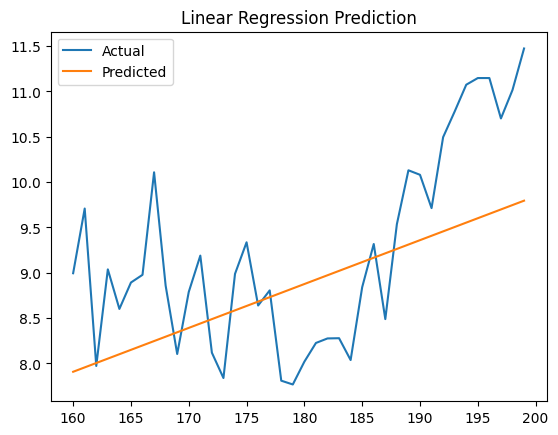

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


data = pd.read_csv('dataset.csv')
X = data[['time']]
y = data['value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

lr_model=LinearRegression()
lr_model.fit(X_train,y_train)

# Prediction

y_pred=lr_model.predict(X_test)

# Evaluation

mse=mean_squared_error(y_test,y_pred)
print("Linear Regression MSE:",mse)

# Plot results

plt.figure()
plt.plot(X_test,y_test,label='Actual')
plt.plot(X_test,y_pred,label='Predicted')
plt.legend()
plt.title('Linear Regression Prediction')
plt.show()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0584
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0126
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0076
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0067 
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0055 
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0048 
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0047 
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0044
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0043 
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0043
Epoch 13/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043
Epoch 14/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0042
Epoch 15/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0042
Epoch 16/20
10/10 ━

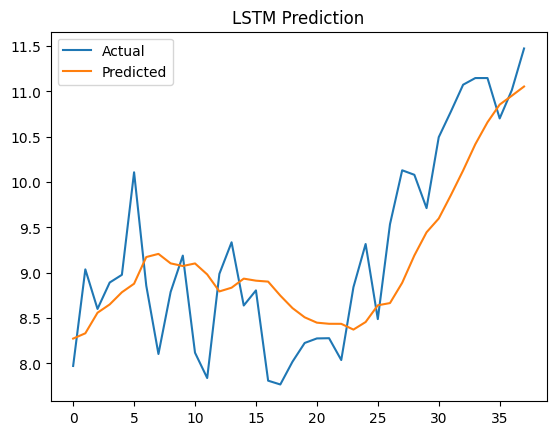

In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from sklearn.metrics import mean_squared_error
from tensorflow.keras.layers import LSTM, Dense


data=pd.read_csv('dataset.csv')
values=data['value'].values.reshape(-1,1)


scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(values)
sequence_length=10

X,y= [], []

for i in range(sequence_length,len(scaled_data)):
   X.append(scaled_data[i-sequence_length:i,0])
   y.append(scaled_data[i,0])

X,y=np.array(X),np.array(y)
X=X.reshape((X.shape[0],X.shape[1],1))

# Train-test split
split=int(0.8*len(X))
X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

# LSTM model
model=Sequential()
model.add(LSTM(50,return_sequences=False,input_shape=(X_train.shape[1],1)))
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')

model.fit(X_train,y_train,epochs=20,batch_size=16,verbose=1)

y_pred=model.predict(X_test)


mse=mean_squared_error(y_test,y_pred)
print("LSTM MSE:",mse)

# Inverse transform
y_test_inv=scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_inv=scaler.inverse_transform(y_pred)

# Plot results
plt.figure()
plt.plot(y_test_inv,label='Actual')
plt.plot(y_pred_inv,label='Predicted')
plt.legend()
plt.title('LSTM Prediction')
plt.show()